In [106]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [107]:
file_path = "ai_impact_student_performance_dataset.csv"
df = pd.read_csv(file_path)

print("Shape:", df.shape)
print(df.info())
print(df.head(3))


Shape: (8000, 26)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 26 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   student_id                       8000 non-null   int64  
 1   age                              8000 non-null   int64  
 2   gender                           8000 non-null   object 
 3   grade_level                      8000 non-null   object 
 4   study_hours_per_day              8000 non-null   float64
 5   uses_ai                          8000 non-null   int64  
 6   ai_usage_time_minutes            8000 non-null   int64  
 7   ai_tools_used                    6638 non-null   object 
 8   ai_usage_purpose                 6654 non-null   object 
 9   ai_dependency_score              8000 non-null   int64  
 10  ai_generated_content_percentage  8000 non-null   int64  
 11  ai_prompts_per_week              8000 non-null   int64  
 12  ai

In [108]:
df = pd.read_csv("ai_impact_student_performance_dataset.csv")
missing_summary = df[["ai_tools_used", "ai_usage_purpose"]].isna().sum()

print("Missing values:")
print(missing_summary)


Missing values:
ai_tools_used       1362
ai_usage_purpose    1346
dtype: int64


In [109]:
df = pd.read_csv("ai_impact_student_performance_dataset.csv")
df["ai_tools_used"] = df["ai_tools_used"].fillna("Unknown")
df["ai_usage_purpose"] = df["ai_usage_purpose"].fillna("Unknown")

print(df[["ai_tools_used", "ai_usage_purpose"]].head())


    ai_tools_used ai_usage_purpose
0         Unknown        Exam Prep
1         Unknown            Notes
2         Copilot    Doubt Solving
3  ChatGPT+Gemini            Notes
4  ChatGPT+Gemini           Coding


In [110]:
df = pd.read_csv("ai_impact_student_performance_dataset.csv")
risk_students = df[(df["ai_dependency_score"] >= 8) & (df["final_score"] < 50)]

print(risk_students[["student_id", "ai_dependency_score", "final_score"]].head(10))
print("Count:", len(risk_students))


     student_id  ai_dependency_score  final_score
0             1                   10         36.8
37           38                    9         46.9
68           69                    8         40.8
69           70                    9         48.5
72           73                   10         49.0
79           80                    9         41.7
93           94                    9         40.0
99          100                   10         46.1
107         108                    9         40.3
115         116                   10         31.9
Count: 740


In [111]:
df = pd.read_csv("ai_impact_student_performance_dataset.csv")
top_students = df.sort_values(by="final_score", ascending=False)

print(top_students[["student_id", "grade_level", "final_score"]].head(10))

      student_id grade_level  final_score
7719        7720        11th         95.8
7980        7981        10th         94.8
4028        4029        10th         94.4
1863        1864    2nd Year         94.3
5302        5303        10th         94.1
5229        5230    3rd Year         93.8
2160        2161    3rd Year         93.5
5477        5478        11th         93.4
6497        6498        10th         93.2
7011        7012    1st Year         93.1


In [112]:
df = pd.read_csv("ai_impact_student_performance_dataset.csv")
grade_summary = df.groupby("grade_level")["final_score"].agg(["mean", "median", "count"])

print(grade_summary.sort_values("mean", ascending=False))

                  mean  median  count
grade_level                          
3rd Year     57.196627    57.3   1334
12th         56.936563    57.4   1321
10th         56.886905    57.2   1344
2nd Year     56.720244    56.6   1309
1st Year     56.698746    56.6   1356
11th         56.434207    56.5   1336


In [113]:
df = pd.read_csv("ai_impact_student_performance_dataset.csv")
ai_comparison = df.groupby("uses_ai")[["final_score", "study_hours_per_day"]].mean()

print(ai_comparison.rename(index={0: "Does not use AI", 1: "Uses AI"}))


                 final_score  study_hours_per_day
uses_ai                                          
Does not use AI    56.841260             3.307730
Uses AI            56.795593             3.275293


In [114]:
df = pd.read_csv("ai_impact_student_performance_dataset.csv")
df["study_efficiency"] = df["final_score"] / df["study_hours_per_day"].clip(lower=0.5)

print(df[["student_id", "study_hours_per_day", "final_score", "study_efficiency"]].head())


   student_id  study_hours_per_day  final_score  study_efficiency
0           1                  2.5         36.8         14.720000
1           2                  3.4         65.5         19.264706
2           3                  0.8         66.3         82.875000
3           4                  4.4         69.5         15.795455
4           5                  3.5         49.7         14.200000


In [115]:
df = pd.read_csv("ai_impact_student_performance_dataset.csv")
df["at_risk"] = ((df["attendance_percentage"] < 60) &
                 (df["concept_understanding_score"] < 5)).astype(int)

print(df["at_risk"].value_counts())

at_risk
0    6877
1    1123
Name: count, dtype: int64


In [116]:
df = pd.read_csv("ai_impact_student_performance_dataset.csv")
percentiles = np.percentile(df["final_score"], [25, 50, 75, 90])

print("Final score percentiles:", percentiles)


Final score percentiles: [47.3 56.9 66.2 74.6]


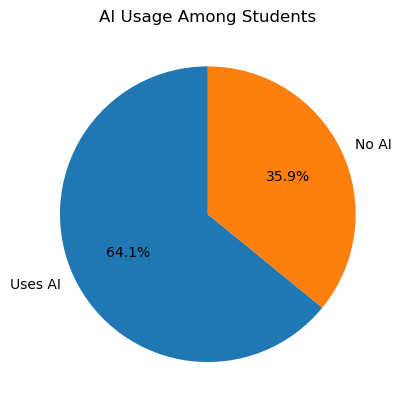

In [117]:
df = pd.read_csv("ai_impact_student_performance_dataset.csv")
ai_counts = df["uses_ai"].map({0: "No AI", 1: "Uses AI"}).value_counts()
plt.pie(ai_counts.values, labels=ai_counts.index, autopct="%1.1f%%", startangle=90)
plt.title("AI Usage Among Students")
plt.show()

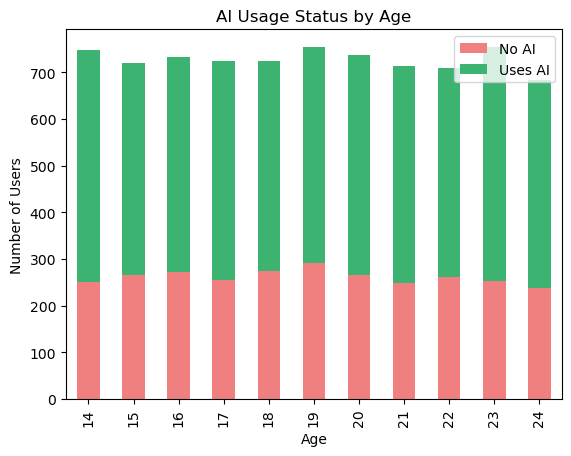

In [118]:
df = pd.read_csv("ai_impact_student_performance_dataset.csv")
age_ai = pd.crosstab(df["age"], df["uses_ai"])

age_ai.plot(kind="bar", stacked=True, color=["lightcoral", "mediumseagreen"])
plt.title("AI Usage Status by Age")
plt.xlabel("Age")
plt.ylabel("Number of Users")
plt.legend(["No AI", "Uses AI"])
plt.show()


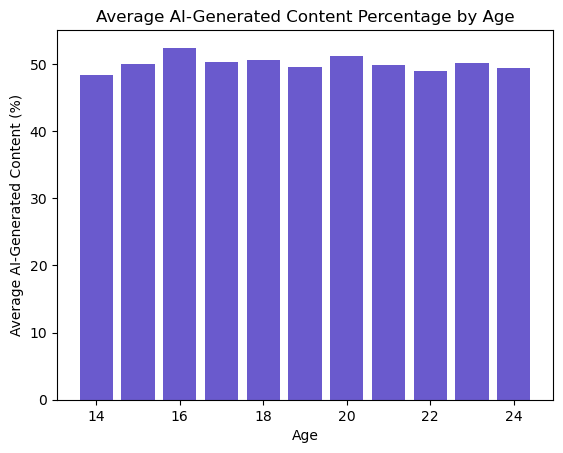

In [119]:
df = pd.read_csv("ai_impact_student_performance_dataset.csv")
age_content = df.groupby("age")["ai_generated_content_percentage"].mean().sort_index()

plt.bar(age_content.index, age_content.values, color="slateblue")
plt.title("Average AI-Generated Content Percentage by Age")
plt.xlabel("Age")
plt.ylabel("Average AI-Generated Content (%)")
plt.show()

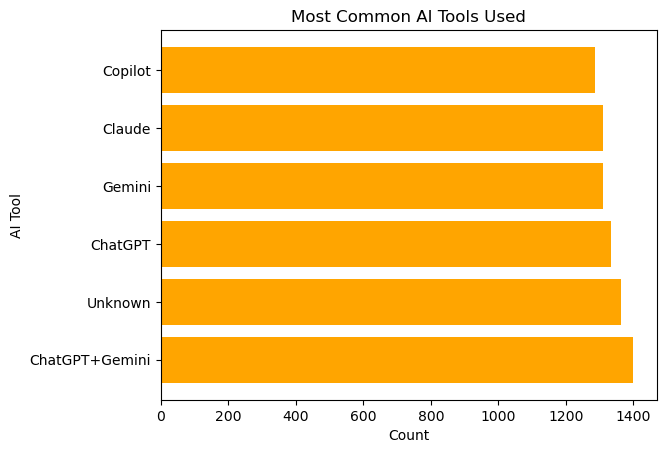

In [120]:
df = pd.read_csv("ai_impact_student_performance_dataset.csv")
tool_counts = df["ai_tools_used"].fillna("Unknown").value_counts().head(8)
plt.barh(tool_counts.index, tool_counts.values, color="orange")
plt.title("Most Common AI Tools Used")
plt.xlabel("Count")
plt.ylabel("AI Tool")
plt.show()


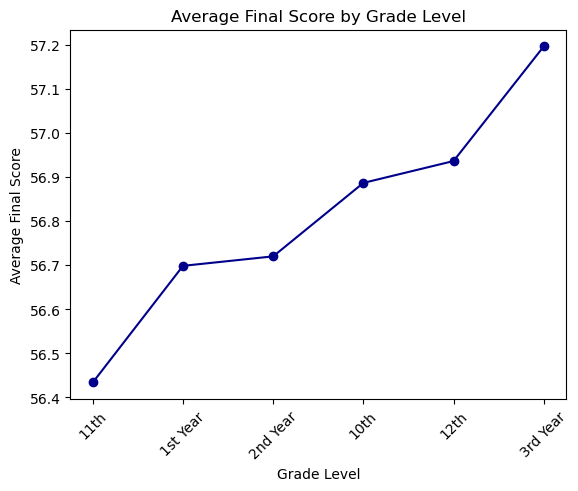

In [121]:
df = pd.read_csv("ai_impact_student_performance_dataset.csv")
avg_scores = df.groupby("grade_level")["final_score"].mean().sort_values()
plt.plot(avg_scores.index, avg_scores.values, marker="o", color="darkblue")
plt.title("Average Final Score by Grade Level")
plt.xlabel("Grade Level")
plt.ylabel("Average Final Score")
plt.xticks(rotation=45)
plt.show()


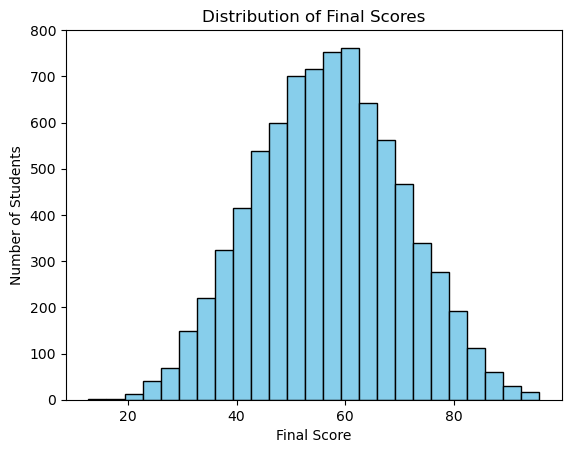

In [122]:
df = pd.read_csv("ai_impact_student_performance_dataset.csv")
plt.hist(df["final_score"], bins=25, color="skyblue", edgecolor="black")
plt.title("Distribution of Final Scores")
plt.xlabel("Final Score")
plt.ylabel("Number of Students")
plt.show()


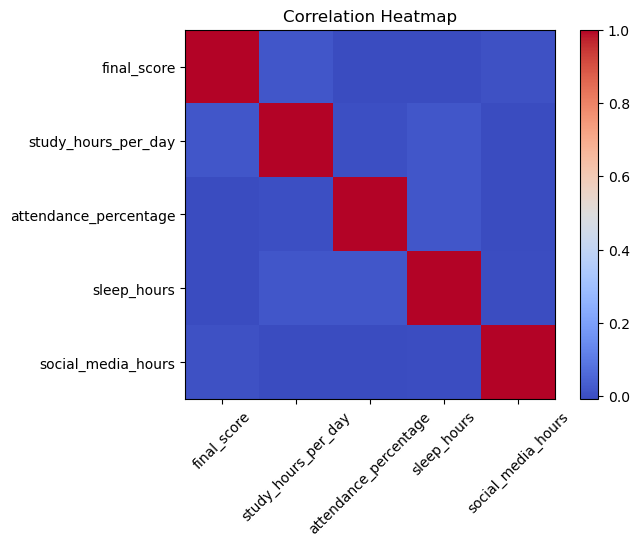

In [123]:
df = pd.read_csv("ai_impact_student_performance_dataset.csv")
cols = ["final_score", "study_hours_per_day", "attendance_percentage", "sleep_hours", "social_media_hours"]
corr_matrix = df[cols].corr()
plt.imshow(corr_matrix, cmap="coolwarm", interpolation="none")
plt.colorbar()
plt.xticks(range(len(cols)), cols, rotation=45)
plt.yticks(range(len(cols)), cols)
plt.title("Correlation Heatmap")
plt.show()


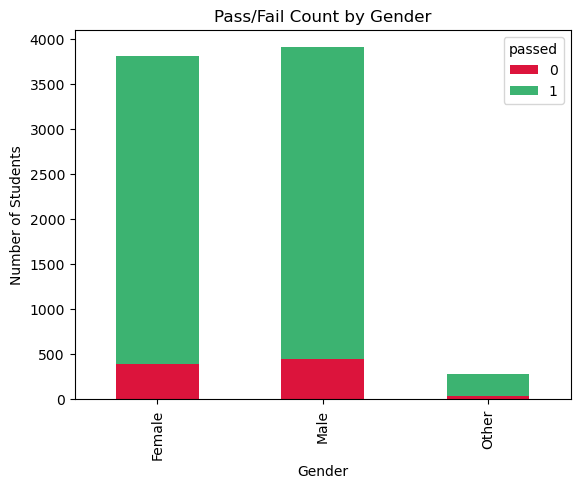

In [124]:
df = pd.read_csv("ai_impact_student_performance_dataset.csv")
result_table = pd.crosstab(df["gender"], df["passed"])
result_table.plot(kind="bar", stacked=True, color=["crimson", "mediumseagreen"])
plt.title("Pass/Fail Count by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Students")
plt.show()


In [125]:
df = pd.read_csv("ai_impact_student_performance_dataset.csv")
df = pd.get_dummies(df, columns=["gender", "grade_level", "ai_tools_used", "ai_usage_purpose"], drop_first=True)
X = df.drop(columns=["student_id", "final_score", "passed", "performance_category"])
y = df["final_score"]


In [126]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(X_train.shape, X_test.shape)


(6400, 33) (1600, 33)


In [127]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)


In [128]:
from sklearn.metrics import mean_squared_error
import numpy as np

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print("MSE:", round(mse, 2))
print("RMSE:", round(rmse, 2))


MSE: 24.06
RMSE: 4.91


In [129]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_pred)
print("MAE:", round(mae, 2))


MAE: 3.89


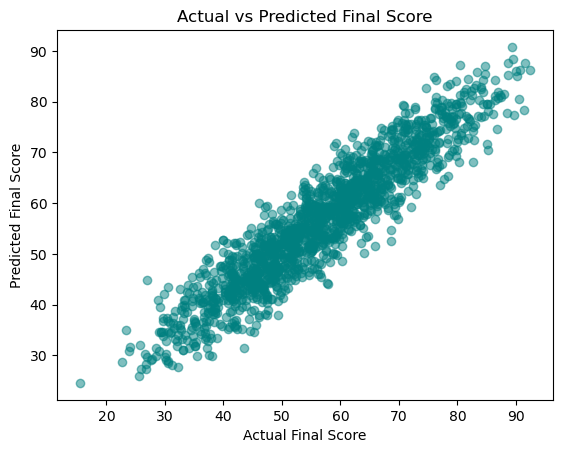

In [130]:
plt.scatter(y_test, y_pred, alpha=0.5, color="teal")
plt.xlabel("Actual Final Score")
plt.ylabel("Predicted Final Score")
plt.title("Actual vs Predicted Final Score")
plt.show()


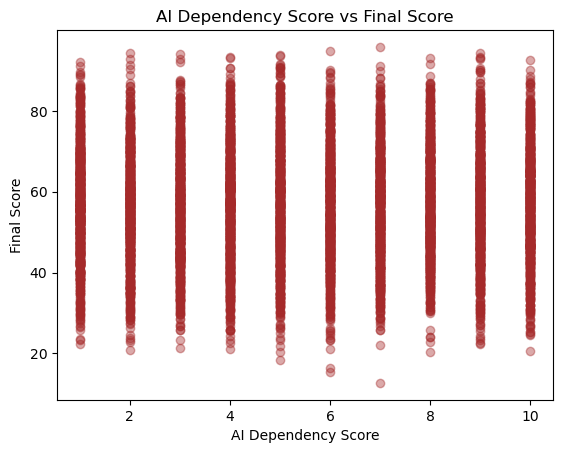

In [131]:
df = pd.read_csv("ai_impact_student_performance_dataset.csv")
plt.scatter(df["ai_dependency_score"], df["final_score"], alpha=0.4, color="brown")
plt.title("AI Dependency Score vs Final Score")
plt.xlabel("AI Dependency Score")
plt.ylabel("Final Score")
plt.show()


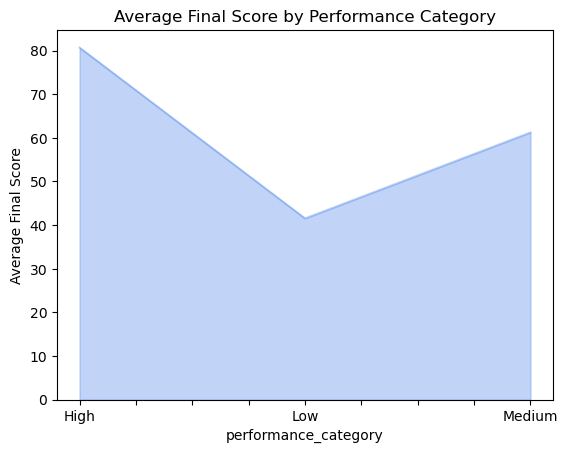

In [132]:
df = pd.read_csv("ai_impact_student_performance_dataset.csv")
avg_category_score = df.groupby("performance_category")["final_score"].mean()
avg_category_score.plot(kind="area", alpha=0.4, color="cornflowerblue")
plt.title("Average Final Score by Performance Category")
plt.ylabel("Average Final Score")
plt.show()
